#  Genetik Algoritma ile Endüstriyel Boya Karışımı Optimizasyonu

**Öğrenci Adı:** Hatukay Duran Alabay  
**Öğrenci No:** 2112721062  
**GitHub Repo Bağlantısı:** https://github.com/Hatukay/UsakYolOptimizasyon

**Proje Amacı:**
Bir fabrikanın boya karışım probleminde, verilen eşitlik ($x_1+x_2=100$) ve eşitsizlik ($x_1 \ge 30$) kısıtlarına uyarak; renk kalitesi puanını ($y$) maksimize eden en uygun pigment oranlarını Genetik Algoritma kullanarak bulmak.

### 1. Kütüphanelerin Yüklenmesi
Matematiksel işlemler, veri yönetimi ve sonuçların görselleştirilmesi için gerekli temel Python kütüphaneleri (NumPy, Matplotlib) projeye dahil edilir.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

%matplotlib inline

print("Kütüphaneler başarıyla yüklendi.")

Kütüphaneler başarıyla yüklendi.


### 2. Problem Tanımı ve GA Parametreleri
Problemin senaryosuna uygun kısıtlar (min/max değerleri) ve algoritmanın çalışma ayarları (popülasyon büyüklüğü, mutasyon oranı, jenerasyon sayısı) bu bölümde tanımlanır.

In [20]:
# --- GENETİK ALGORİTMA PARAMETRELERİ ---
POPULASYON_BOYUTU = 50   # Popülasyon büyüklüğü
GEN_SAYISI = 2           # Gen sayısı (x1 ve x2)
JENERASYON_SAYISI = 100  # Jenerasyon (nesil) sayısı
MUTASYON_ORANI = 0.1     # Mutasyon ihtimali
ELITIZM_SAYISI = 2       # Bir sonraki nesle doğrudan aktarılacak en iyi birey sayısı

# --- KISITLAR ---
# x1 + x2 = 100
# x1 >= 30
MIN_X1 = 30
MAX_X1 = 100

### 3. Birey Oluşturma ve Uygunluk (Fitness) Fonksiyonu
* **create_individual:** Kısıtları ($x_1+x_2=100$) sağlayan geçerli kromozomlar üretir.
* **fitness_function:** Her bireyin başarısını amaç fonksiyonuna ($y = 5x_1 + 2x_2 - x_1x_2$) göre puanlar. Kısıtları ihlal eden bireyler ceza puanı alır.

In [21]:
def birey_olustur():
    """
    Kısıtları sağlayan rastgele bir birey oluşturur.
    Kısıt 1: x1 >= 30
    Kısıt 2: x1 + x2 = 100
    """
    # x1 için [30, 100] arasında rastgele değer seçilir.
    x1 = random.uniform(MIN_X1, MAX_X1)

    # x2 otomatik olarak 100 - x1 olur (Toplam kısıtını sağlamak için)
    x2 = 100 - x1

    return [x1, x2]

def populasyon_olustur(boyut):
    """Belirtilen boyutta popülasyon oluşturur."""
    return [birey_olustur() for _ in range(boyut)]

def uygunluk_fonksiyonu(birey):
    """
    Bireyin uygunluk değerini (fitness) hesaplar.
    Formül: y = 5x1 + 2x2 - x1x2
    """
    x1 = birey[0]
    x2 = birey[1]

    # Kısıt Kontrolü (Güvenlik amaçlı)
    # Eğer x1 30'dan küçükse veya toplam 100 değilse çok düşük puan ver (Ceza Yöntemi)
    if x1 < 30 or not (99.9 <= (x1 + x2) <= 100.1):
        return -99999 # Geçersiz çözüm

    puan = (5 * x1) + (2 * x2) - (x1 * x2)
    return puan

### 4. Genetik Operatörler
Evrim sürecini simüle eden temel mekanizmalar:
1.  **Seçilim (Tournament):** İyi genlere sahip bireylerin bir sonraki nesle aktarılma şansını artırır.
2.  **Çaprazlama (Crossover):** Ebeveynlerin genlerini karıştırarak (aritmetik ortalama ile) yeni bireyler üretir.
3.  **Mutasyon:** Genetik çeşitliliği korumak ve yerel maksimumdan kaçmak için genlerde rastgele değişimler yapar.

In [22]:
def turnuva_secimi(populasyon, k=3):
    """
    Turnuva seçimi: Rastgele k birey seçilir, en iyisi kazanır.
    """
    secilenler = random.sample(populasyon, k)
    secilenler.sort(key=uygunluk_fonksiyonu, reverse=True) # Büyükten küçüğe sırala
    return secilenler[0]

def caprazlama(ebeveyn1, ebeveyn2):
    """
    Aritmetik Çaprazlama: İki ebeveynin ağırlıklı ortalamasını alır.
    """
    alfa = random.random() # 0 ile 1 arasında ağırlık

    # Yeni x1 değeri
    cocuk1_x1 = alfa * ebeveyn1[0] + (1 - alfa) * ebeveyn2[0]
    cocuk2_x1 = (1 - alfa) * ebeveyn1[0] + alfa * ebeveyn2[0]

    # Kısıtları onar (Repair)
    # x1 değerleri sınırların dışına çıkarsa düzelt
    cocuk1_x1 = max(MIN_X1, min(MAX_X1, cocuk1_x1))
    cocuk2_x1 = max(MIN_X1, min(MAX_X1, cocuk2_x1))

    # x2 değerlerini x1'e göre türet
    cocuk1 = [cocuk1_x1, 100 - cocuk1_x1]
    cocuk2 = [cocuk2_x1, 100 - cocuk2_x1]

    return cocuk1, cocuk2

def mutasyon(birey, mutasyon_orani=0.1, adim_buyuklugu=5.0):
    """
    Mutasyon: Bireyin genlerinde ufak rastgele değişiklikler yapar.
    """
    if random.random() < mutasyon_orani:
        # x1'e rastgele bir değer ekle veya çıkar
        degisim = random.uniform(-adim_buyuklugu, adim_buyuklugu)
        yeni_x1 = birey[0] + degisim

        # Sınırları tekrar kontrol et (x1 >= 30 ve x1 <= 100)
        yeni_x1 = max(MIN_X1, min(MAX_X1, yeni_x1))

        # Bireyi güncelle
        birey[0] = yeni_x1
        birey[1] = 100 - yeni_x1

    return birey

### 5. Algoritmanın Çalıştırılması (Ana Döngü)
Belirlenen jenerasyon sayısı boyunca popülasyon evrilir. Her adımda *Seçilim -> Çaprazlama -> Mutasyon* döngüsü uygulanır ve **Elitizm** ile en iyi bireyler korunur.

In [23]:
# 1. Başlangıç Popülasyonu
populasyon = populasyon_olustur(POPULASYON_BOYUTU)

en_iyi_uygunluk_gecmisi = [] # Grafik çizimi için geçmişi tut
en_iyi_cozum = None

print(f"Genetik Algoritma Başlatılıyor... ({JENERASYON_SAYISI} Jenerasyon)")

for jenerasyon in range(JENERASYON_SAYISI):
    # Mevcut popülasyonu fitness değerine göre sırala (En iyi en başta)
    populasyon.sort(key=uygunluk_fonksiyonu, reverse=True)

    # En iyi bireyi kaydet
    mevcut_en_iyi = populasyon[0]
    en_iyi_puan = uygunluk_fonksiyonu(mevcut_en_iyi)
    en_iyi_uygunluk_gecmisi.append(en_iyi_puan)
    en_iyi_cozum = mevcut_en_iyi

    # Yeni nesil listesi (Elitizm: En iyi bireyleri koru)
    yeni_populasyon = populasyon[:ELITIZM_SAYISI]

    # Popülasyon dolana kadar çocuk üret
    while len(yeni_populasyon) < POPULASYON_BOYUTU:
        # Seçilim
        ebeveyn1 = turnuva_secimi(populasyon)
        ebeveyn2 = turnuva_secimi(populasyon)

        # Çaprazlama
        cocuk1, cocuk2 = caprazlama(ebeveyn1, ebeveyn2)

        # Mutasyon
        cocuk1 = mutasyon(cocuk1, MUTASYON_ORANI)
        cocuk2 = mutasyon(cocuk2, MUTASYON_ORANI)

        # Yeni bireyleri ekle
        yeni_populasyon.append(cocuk1)
        if len(yeni_populasyon) < POPULASYON_BOYUTU:
            yeni_populasyon.append(cocuk2)

    # Popülasyonu güncelle
    populasyon = yeni_populasyon

print("\n--- OPTİMİZASYON TAMAMLANDI ---")
print(f"En İyi Çözüm Değerleri:")
print(f"Pigment A Oranı (x1): %{en_iyi_cozum[0]:.2f}")
print(f"Pigment B Oranı (x2): %{en_iyi_cozum[1]:.2f}")
print(f"Maksimum Renk Kalitesi Puanı: {uygunluk_fonksiyonu(en_iyi_cozum):.4f}")

Genetik Algoritma Başlatılıyor... (100 Jenerasyon)

--- OPTİMİZASYON TAMAMLANDI ---
En İyi Çözüm Değerleri:
Pigment A Oranı (x1): %100.00
Pigment B Oranı (x2): %0.00
Maksimum Renk Kalitesi Puanı: 500.0000


### 6. Sonuçların Görselleştirilmesi ve Analiz
Algoritmanın gelişim süreci (Fitness değerinin değişimi) grafiğe dökülür ve bulunan en iyi pigment oranları ekrana yazdırılır.

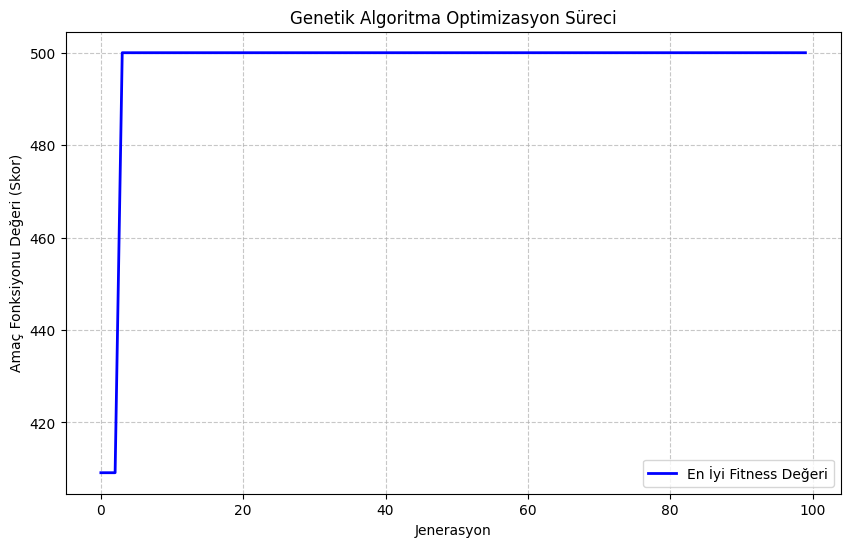

Grafik Analizi:
Algoritma, ilk jenerasyonlarda hızlı bir yükseliş göstermiş ve
belirli bir noktadan sonra en iyi çözüme yakınsayarak (convergence) sabitlenmiştir.
x1 ve x2 toplamı 100 kısıtına sadık kalınarak en yüksek puan hedeflenmiştir.


In [24]:
# Gelişim Grafiği
plt.figure(figsize=(10, 6))
plt.plot(en_iyi_uygunluk_gecmisi, label='En İyi Fitness Değeri', color='blue', linewidth=2)
plt.title('Genetik Algoritma Optimizasyon Süreci')
plt.xlabel('Jenerasyon')
plt.ylabel('Amaç Fonksiyonu Değeri (Skor)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# Sonuç Yorumu
print("Grafik Analizi:")
print("Algoritma, ilk jenerasyonlarda hızlı bir yükseliş göstermiş ve")
print("belirli bir noktadan sonra en iyi çözüme yakınsayarak (convergence) sabitlenmiştir.")
print("x1 ve x2 toplamı 100 kısıtına sadık kalınarak en yüksek puan hedeflenmiştir.")

### Grafik Analizi ve Sonuç Yorumu

Grafikte görüldüğü üzere, algoritma ilk jenerasyonlarda çok hızlı bir öğrenme süreci geçirmiş ve optimum değer olan **500 puanına** ($x_1=\%100, x_2=\%0$) kısa sürede ulaşmıştır.

Sonraki jenerasyonlarda skorun değişmemesi, algoritmanın **global maksimum** noktasına başarıyla yakınsadığını  ve bu en iyi çözümü koruduğunu gösterir.